In [1]:
import kagglehub
path = kagglehub.dataset_download(
    "crowdflower/twitter-airline-sentiment"
)
print(path)

100%|██████████| 2.55M/2.55M [00:01<00:00, 2.59MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4


In [2]:
import os
import pandas as pd

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "Tweets.csv"))

df.head()

['database.sqlite', 'Tweets.csv']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 14640
Columns : 15


In [5]:
df.isnull().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,5462
negativereason_confidence,4118
airline,0
airline_sentiment_gold,14600
name,0
negativereason_gold,14608
retweet_count,0


In [6]:
df.dropna(subset=["text","airline_sentiment"], inplace=True)

df.isnull().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,5462
negativereason_confidence,4118
airline,0
airline_sentiment_gold,14600
name,0
negativereason_gold,14608
retweet_count,0


In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 36


In [8]:
df.drop_duplicates(inplace=True)

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
df = df[["text","airline_sentiment"]]

df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [10]:
df.columns = [
    "Tweet",
    "Sentiment"
]

df.head()

,Tweet,Sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


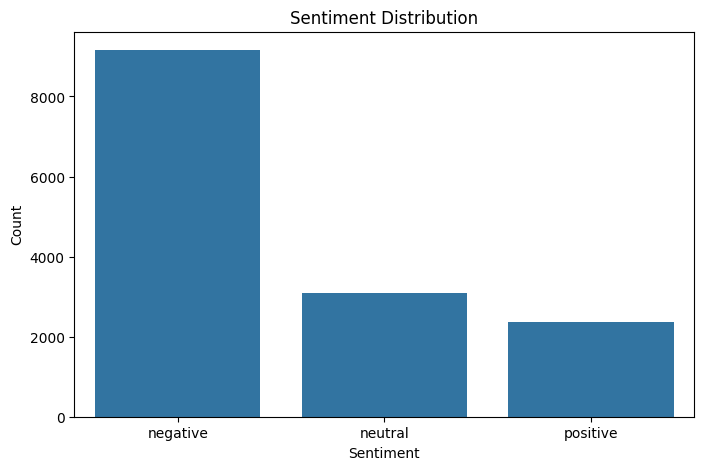

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [12]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [13]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [14]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [15]:
df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

df.head()

,Tweet,Sentiment,Clean_Tweet
0,@VirginAmerica What @dhepburn said.,neutral,said
1,@VirginAmerica plus you've added commercials t...,positive,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,neutral,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,negative,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,negative,really big bad thing


In [16]:
df[["Tweet","Clean_Tweet"]].head(10)

,Tweet,Clean_Tweet
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat didnt playing ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly vx “ear worm” won’t ...
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well didnt…but
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early youre good


In [17]:
df["Tweet_Length"] = df["Tweet"].astype(str).apply(len)

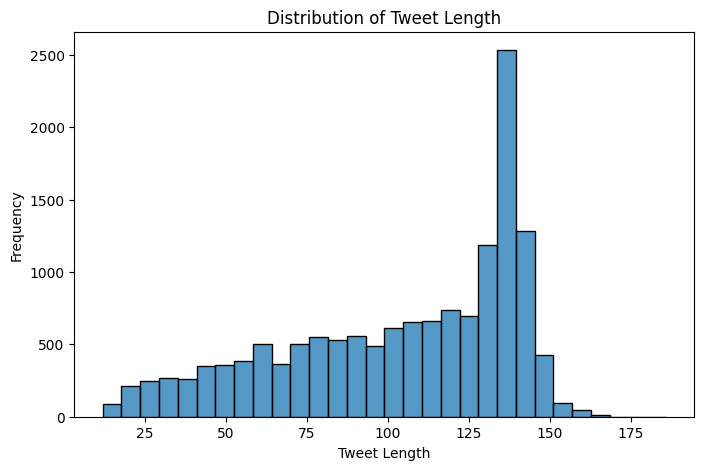

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Tweet_Length"], bins=30)

plt.title("Distribution of Tweet Length")

plt.xlabel("Tweet Length")

plt.ylabel("Frequency")

plt.show()

In [19]:
from wordcloud import WordCloud

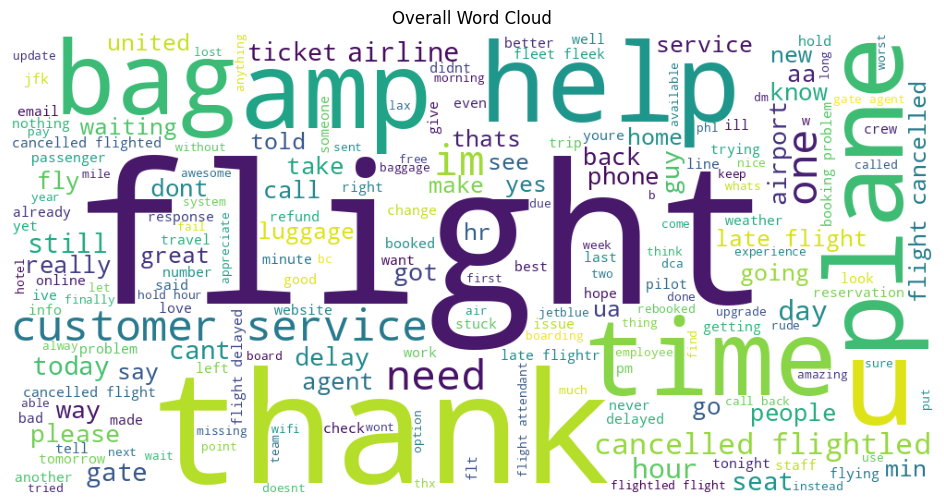

In [20]:
text = " ".join(df["Clean_Tweet"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Overall Word Cloud")

plt.show()

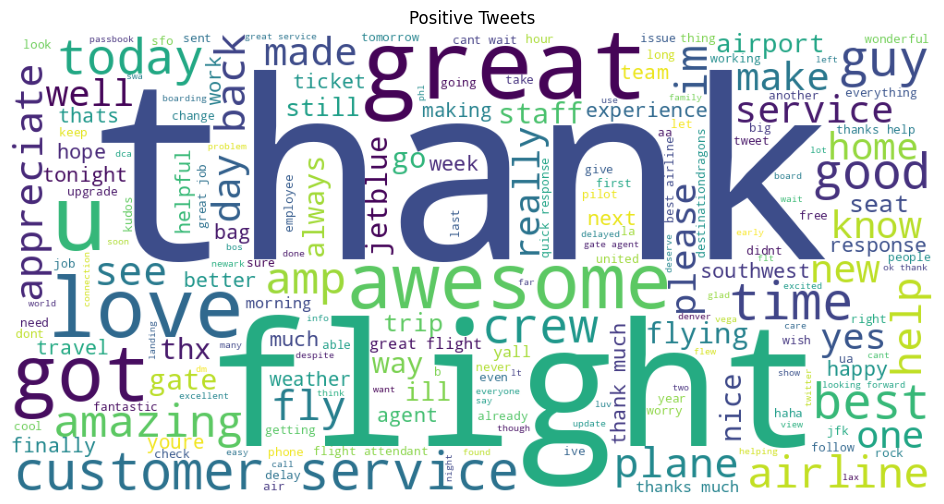

In [21]:
positive = " ".join(
    df[df["Sentiment"]=="positive"]["Clean_Tweet"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets")

plt.show()

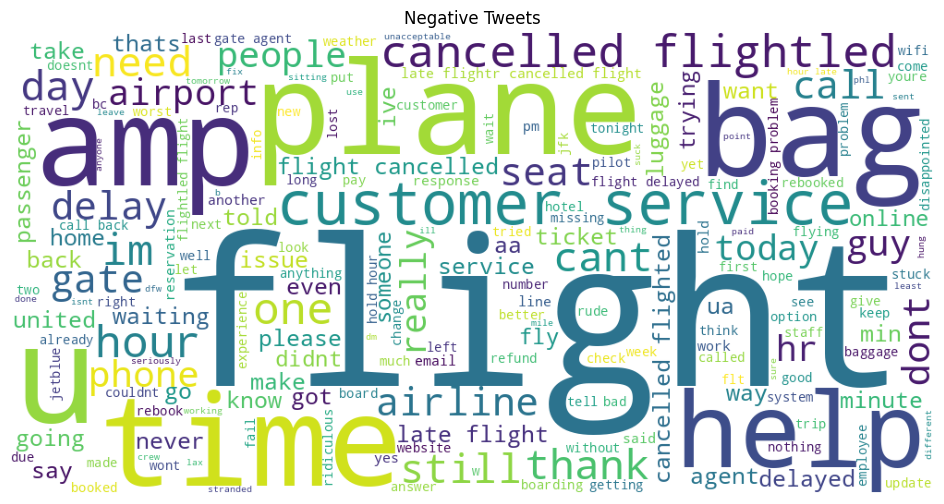

In [22]:
negative = " ".join(
    df[df["Sentiment"]=="negative"]["Clean_Tweet"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Tweets")

plt.show()

In [23]:
from collections import Counter

words = " ".join(df["Clean_Tweet"]).split()

common = Counter(words).most_common(20)

common_df = pd.DataFrame(
    common,
    columns=["Word","Frequency"]
)

common_df

,Word,Frequency
0,flight,4527
1,get,1372
2,hour,1148
3,thanks,1066
4,cancelled,1050
5,u,1031
6,service,982
7,time,939
8,customer,927
9,help,857


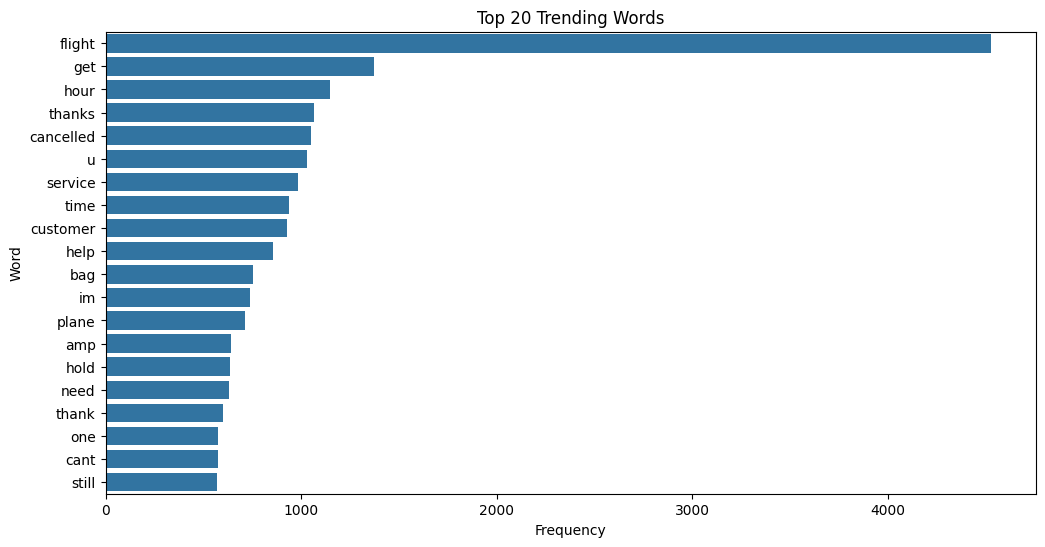

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Trending Words")

plt.show()

In [25]:
df["Sentiment"] = df["Sentiment"].replace({
    "negative":0,
    "neutral":1,
    "positive":2
})

df.head()

/tmp/ipykernel_495/1699849800.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sentiment"] = df["Sentiment"].replace({


,Tweet,Sentiment,Clean_Tweet,Tweet_Length
0,@VirginAmerica What @dhepburn said.,1,said,35
1,@VirginAmerica plus you've added commercials t...,2,plus youve added commercial experience tacky,72
2,@VirginAmerica I didn't today... Must mean I n...,1,didnt today must mean need take another trip,71
3,@VirginAmerica it's really aggressive to blast...,0,really aggressive blast obnoxious entertainmen...,126
4,@VirginAmerica and it's a really big bad thing...,0,really big bad thing,55


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Tweet"])

y = df["Sentiment"]

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.781581650119822


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1832
           1       0.66      0.51      0.57       618
           2       0.79      0.55      0.65       471

    accuracy                           0.78      2921
   macro avg       0.75      0.66      0.70      2921
weighted avg       0.77      0.78      0.77      2921



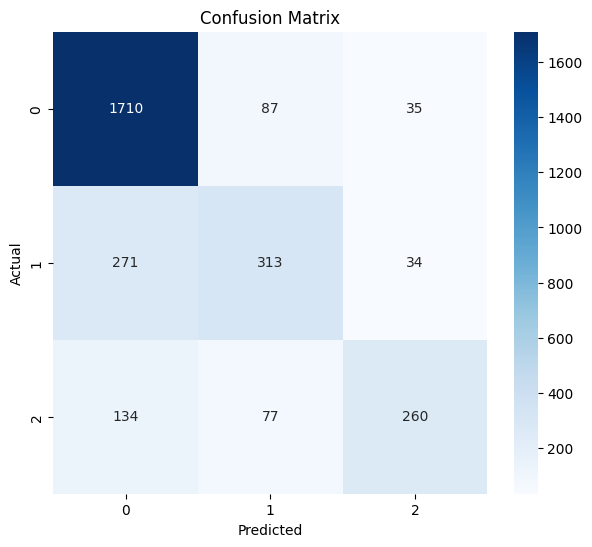

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

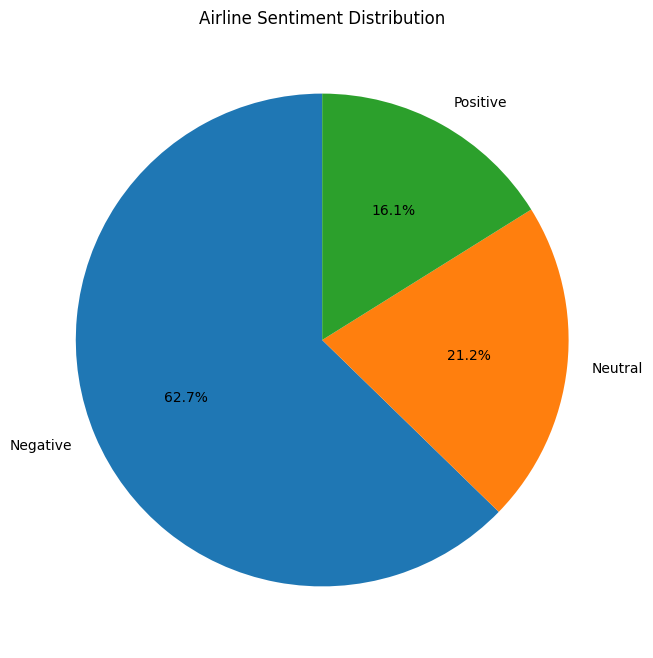

In [32]:
labels = ["Negative","Neutral","Positive"]

sizes = df["Sentiment"].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Airline Sentiment Distribution")

plt.show()

In [33]:
def predict_sentiment(comment):

    comment = clean_text(comment)

    vector = tfidf.transform([comment])

    prediction = lr.predict(vector)[0]

    labels = {
        0:"Negative",
        1:"Neutral",
        2:"Positive"
    }

    print("Predicted Sentiment :",labels[prediction])

In [34]:
predict_sentiment(
    "The flight was excellent and the staff were very friendly."
)

predict_sentiment(
    "Worst airline ever. Flight delayed for 6 hours."
)

predict_sentiment(
    "The flight was okay, nothing special."
)

Predicted Sentiment : Positive
Predicted Sentiment : Negative
Predicted Sentiment : Negative
